In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("job_salary_prediction_dataset.csv")

In [3]:
df.head(11)

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
5,AI Engineer,0,High School,4,Education,Enterprise,USA,No,2,180351
6,Backend Developer,6,High School,16,Manufacturing,Enterprise,Canada,No,3,165375
7,Machine Learning Engineer,4,Bachelor,18,Healthcare,Enterprise,Canada,Hybrid,5,202463
8,AI Engineer,5,Diploma,14,Telecom,Enterprise,Singapore,Yes,0,171834
9,Frontend Developer,18,PhD,2,Retail,Enterprise,India,Hybrid,5,128377


#### Data Cleaning

In [4]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


In [5]:
pd.isnull(df).sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [7]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
249995    False
249996    False
249997    False
249998    False
249999    False
Length: 250000, dtype: bool

### Univariate Analysis (single column)

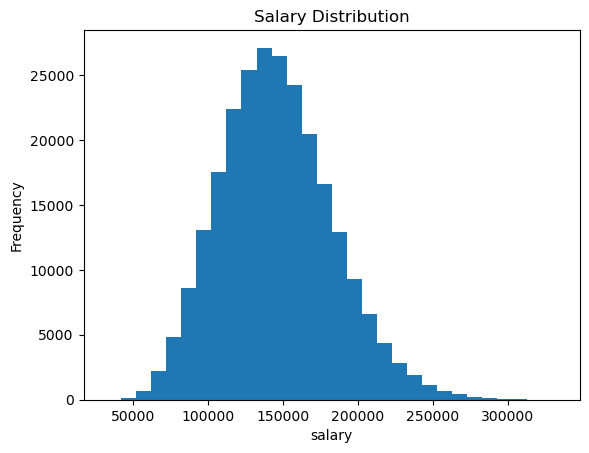

In [8]:
# Salary Distribution

plt.hist(df['salary'], bins=30)
plt.title("Salary Distribution")
plt.xlabel("salary")
plt.ylabel("Frequency")
plt.show()

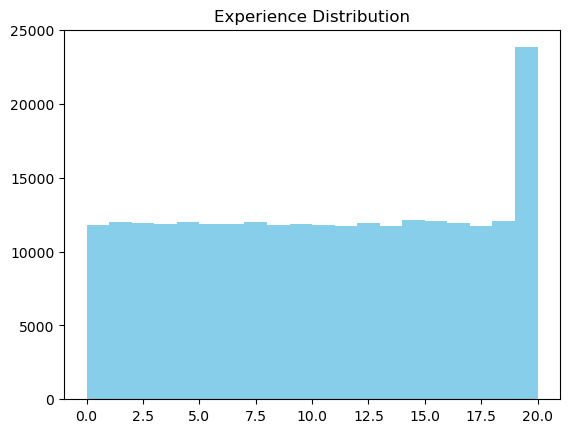

In [9]:
# Experience Distribution

plt.hist(df['experience_years'], bins=20, color="skyblue")
plt.title("Experience Distribution")
plt.show()

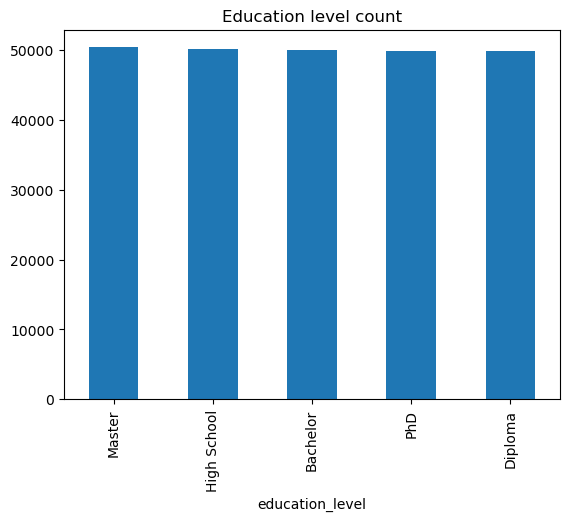

In [10]:
# Educationn level count
df['education_level'].value_counts().plot(kind='bar')
plt.title("Education level count")
plt.show()

### Bivariate Analysis (2 Variables)

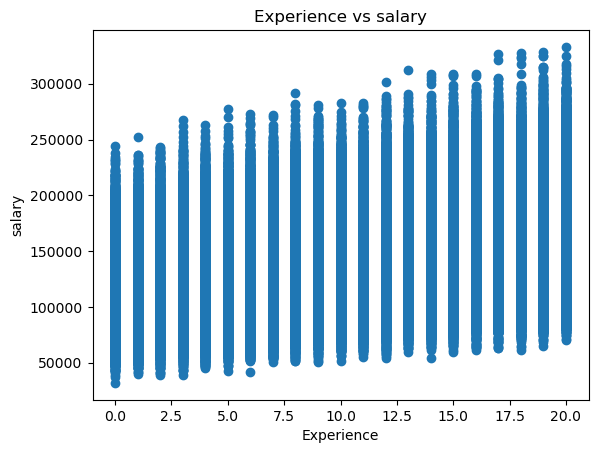

In [11]:
# Salary vs Experience
plt.scatter(df['experience_years'], df['salary'])
plt.xlabel("Experience")
plt.ylabel("salary")
plt.title("Experience vs salary")
plt.show()

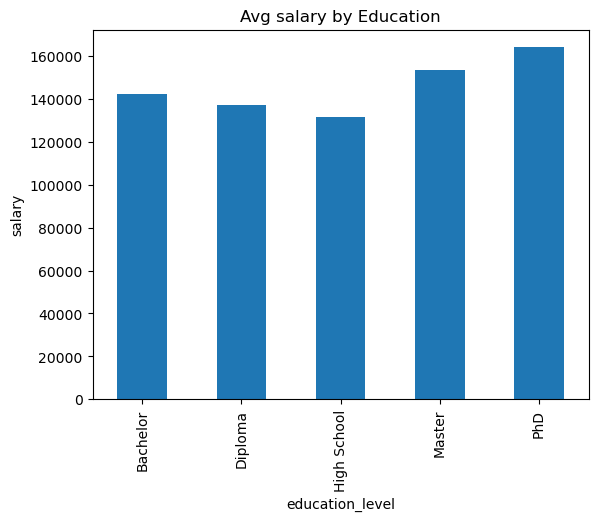

In [13]:
# Salary by Education

df.groupby('education_level')['salary'].mean().plot(kind='bar')
plt.title("Avg salary by Education")
plt.ylabel("salary")
plt.show()

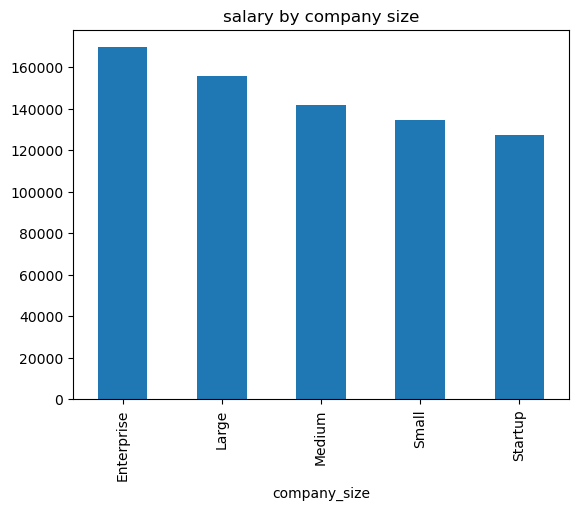

In [14]:
# Salary by company size

df.groupby('company_size')['salary'].mean().plot(kind='bar')
plt.title("salary by company size")
plt.show()

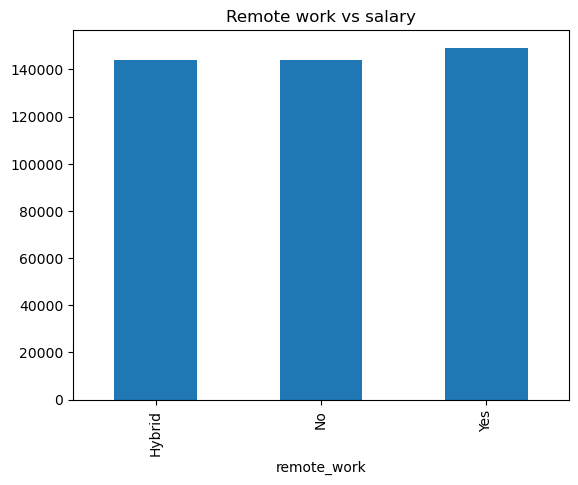

In [15]:
# Remote work impact

df.groupby('remote_work')['salary'].mean().plot(kind='bar')
plt.title("Remote work vs salary")
plt.show()

### Multivariate Analysis (multi variant more than 2)

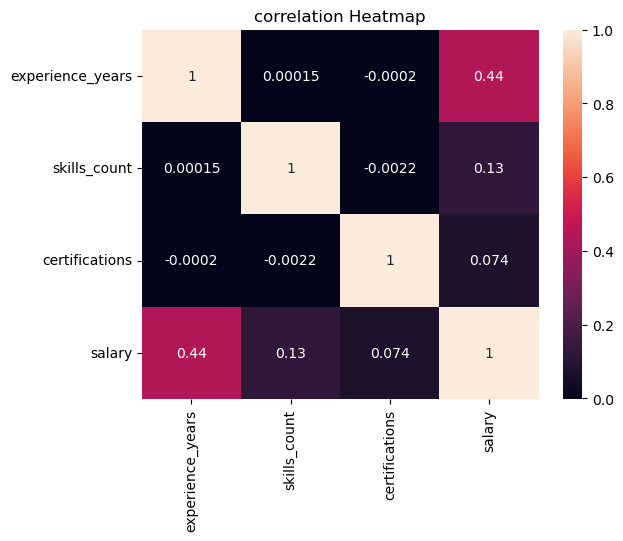

In [16]:
# correlation heatmap

corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title("correlation Heatmap")
plt.show()

### Features insights

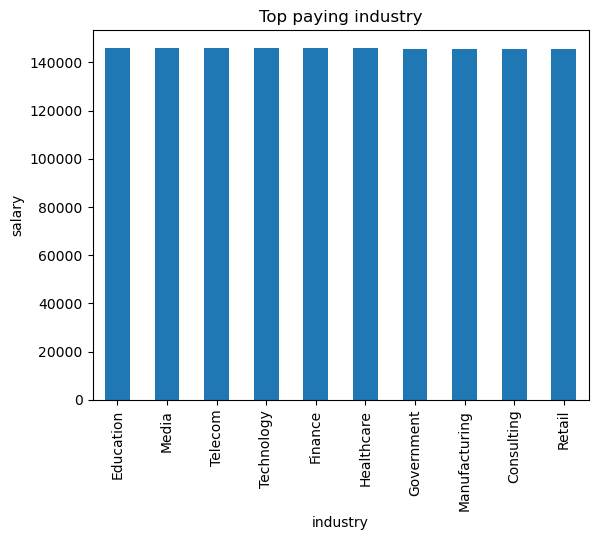

In [18]:
# Top paying industry

top_industry = df.groupby('industry')['salary'].mean().sort_values(ascending=False)
top_industry.head(10).plot(kind='bar')
plt.title("Top paying industry")
plt.ylabel("salary")
plt.show()

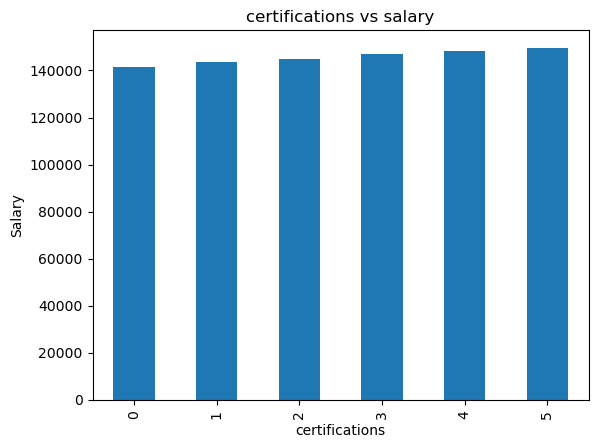

In [21]:
# certification impact

df.groupby('certifications')['salary'].mean().plot(kind='bar')
plt.title("certifications vs salary")
plt.ylabel("Salary")
plt.show()

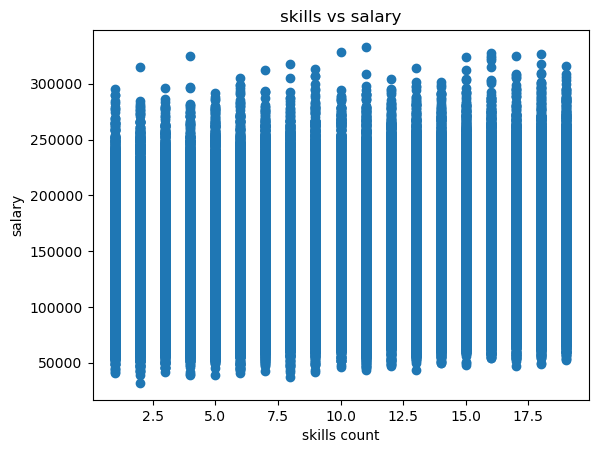

In [26]:
# skill count vs salary

plt.scatter(df['skills_count'], df['salary'])
plt.title("skills vs salary")
plt.xlabel("skills count")
plt.ylabel("salary")
plt.show()

### Advance Practice

In [31]:
# salary by location

df.groupby('location')['salary'].mean().sort_values().tail(10).reset_index()

,location,salary
0,India,97690.402249
1,Netherlands,139294.813644
2,Singapore,139340.696625
3,Australia,139362.150804
4,Sweden,139440.637291
5,Remote,139442.525155
6,Germany,153376.211000
7,UK,160075.143018
8,Canada,167391.273396
9,USA,181716.303919


C:\Users\PALLAVI SAHU\AppData\Local\Temp\ipykernel_5824\3396471286.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('exp_group')['salary'].mean().plot(kind='bar')


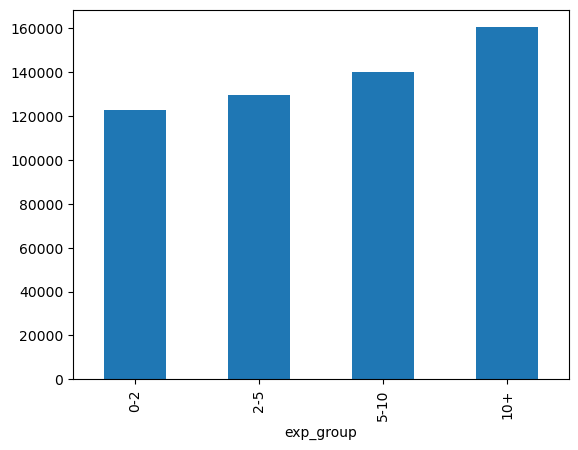

In [35]:
# experience grouping

df['exp_group'] = pd.cut(df['experience_years'], bins=[0,2,5,10,20], labels=['0-2', '2-5', '5-10', '10+'])

df.groupby('exp_group')['salary'].mean().plot(kind='bar')
plt.show()


### key insights

1. salary increase with experience
2. Higher education higher education salary
3. More skill better salary
4. Remote jobs may have different salary patterns
5. certifications give salary boots